In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import lime
import lime.lime_tabular
import joblib
import warnings
warnings.filterwarnings('ignore')

/Users/vaishnavikolli/Desktop/Project/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Models
xgb_model     = joblib.load('../models/xgboost_model.pkl')
lr_model      = joblib.load('../models/logistic_regression.pkl')
scaler        = joblib.load('../models/scaler.pkl')
feature_names = joblib.load('../models/feature_names.pkl')
explainer_xgb = joblib.load('../models/explainer_xgb.pkl')

# Data
X_test  = pd.read_csv('../data/X_test.csv')
y_test  = pd.read_csv('../data/y_test.csv').squeeze()
X_train = pd.read_csv('../data/X_train.csv')

# Reset index — critical, prevents shape mismatch errors
X_test  = X_test.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)
X_train = X_train.reset_index(drop=True)

# SHAP values from Day 2
shap_values_xgb = np.load('../data/shap_values_xgb.npy')

print("Everything loaded ✓")
print(f"X_test shape: {X_test.shape}")

Everything loaded ✓
X_test shape: (1407, 19)


In [3]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data  = X_train.values,
    feature_names  = feature_names,
    class_names    = ['No Churn', 'Churn'],
    mode           = 'classification',
    discretize_continuous = True,
    random_state   = 42
)

print("LIME explainer ready ✓")

LIME explainer ready ✓


In [4]:
# Same indices as Day 2
churn_indices    = y_test[y_test == 1].index[:3].tolist()
no_churn_indices = y_test[y_test == 0].index[:2].tolist()
sample_indices   = churn_indices + no_churn_indices

print("Sample indices:", sample_indices)
print("Actual labels:", y_test.loc[sample_indices].tolist())

Sample indices: [3, 5, 8, 0, 1]
Actual labels: [1, 1, 1, 0, 0]



Customer 3 | Actual: Churn | Predicted: No Churn | Churn Probability: 11.37%


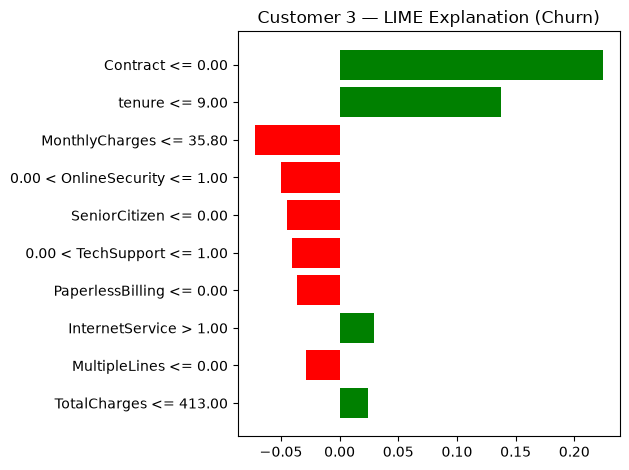


Customer 5 | Actual: Churn | Predicted: Churn | Churn Probability: 52.47%


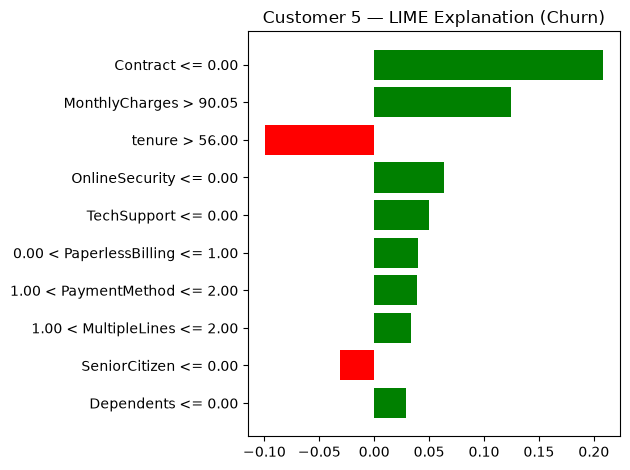


Customer 8 | Actual: Churn | Predicted: Churn | Churn Probability: 64.37%


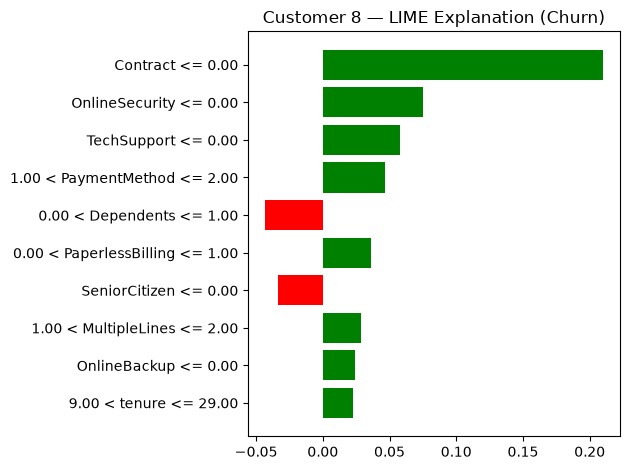


Customer 0 | Actual: No Churn | Predicted: No Churn | Churn Probability: 1.02%


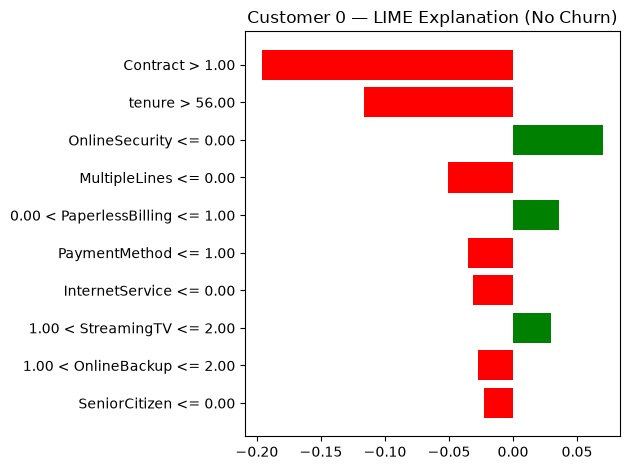


Customer 1 | Actual: No Churn | Predicted: Churn | Churn Probability: 75.35%


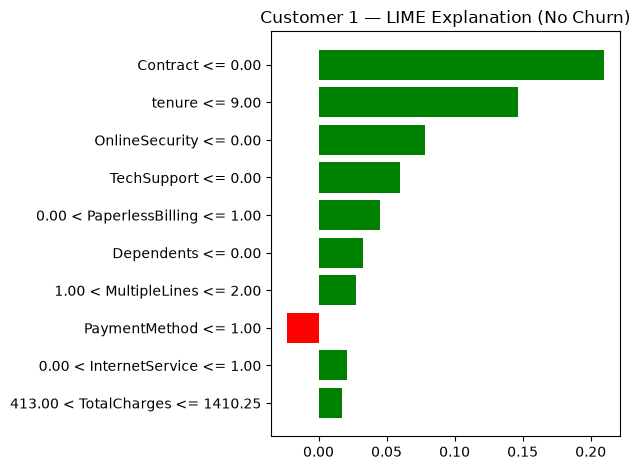

In [5]:
lime_explanations = {}

for idx in sample_indices:
    actual    = y_test.loc[idx]
    predicted = xgb_model.predict(X_test.loc[[idx]])[0]
    prob      = xgb_model.predict_proba(X_test.loc[[idx]])[0][1]

    print(f"\nCustomer {idx} | Actual: {'Churn' if actual else 'No Churn'} | "
          f"Predicted: {'Churn' if predicted else 'No Churn'} | "
          f"Churn Probability: {prob:.2%}")

    # Get LIME explanation
    exp = lime_explainer.explain_instance(
        data_row       = X_test.iloc[idx].values,
        predict_fn     = xgb_model.predict_proba,
        num_features   = 10,
        num_samples    = 1000
    )

    lime_explanations[idx] = exp

    # Save plot
    fig = exp.as_pyplot_figure()
    plt.title(f"Customer {idx} — LIME Explanation ({'Churn' if actual else 'No Churn'})")
    plt.tight_layout()
    plt.savefig(f'../data/lime_explanation_{idx}.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

In [6]:
divergence_results = []

for idx in sample_indices:
    # --- SHAP top features ---
    shap_vals  = shap_values_xgb[idx]
    shap_series = pd.Series(
        np.abs(shap_vals),
        index=feature_names
    ).sort_values(ascending=False)
    shap_top5 = shap_series.head(5).index.tolist()

    # --- LIME top features ---
    lime_exp      = lime_explanations[idx]
    lime_features = lime_exp.as_list()
    # LIME returns (feature_description, weight) tuples
    lime_top5 = [f[0] for f in sorted(
        lime_features, key=lambda x: abs(x[1]), reverse=True
    )[:5]]

    # --- Divergence score ---
    # Count how many top-5 features appear in both
    # Lower overlap = higher divergence
    overlap = len(set(shap_top5) & set(lime_top5))
    divergence_score = 5 - overlap  # 0 = perfect agreement, 5 = total disagreement

    divergence_results.append({
        'customer_idx'     : idx,
        'actual'           : 'Churn' if y_test.loc[idx] == 1 else 'No Churn',
        'churn_prob'       : round(xgb_model.predict_proba(X_test.loc[[idx]])[0][1], 3),
        'shap_top5'        : shap_top5,
        'lime_top5'        : lime_top5,
        'overlap'          : overlap,
        'divergence_score' : divergence_score
    })

    print(f"\nCustomer {idx} ({('Churn' if y_test.loc[idx] == 1 else 'No Churn')})")
    print(f"  SHAP top 5: {shap_top5}")
    print(f"  LIME top 5: {lime_top5}")
    print(f"  Overlap: {overlap}/5 | Divergence Score: {divergence_score}/5")

divergence_df = pd.DataFrame(divergence_results)
divergence_df.to_csv('../data/divergence_results.csv', index=False)
print("\nDivergence results saved ✓")


Customer 3 (Churn)
  SHAP top 5: ['Contract', 'OnlineSecurity', 'MonthlyCharges', 'tenure', 'TechSupport']
  LIME top 5: ['Contract <= 0.00', 'tenure <= 9.00', 'MonthlyCharges <= 35.80', '0.00 < OnlineSecurity <= 1.00', 'SeniorCitizen <= 0.00']
  Overlap: 0/5 | Divergence Score: 5/5

Customer 5 (Churn)
  SHAP top 5: ['tenure', 'MonthlyCharges', 'Contract', 'OnlineSecurity', 'PaymentMethod']
  LIME top 5: ['Contract <= 0.00', 'MonthlyCharges > 90.05', 'tenure > 56.00', 'OnlineSecurity <= 0.00', 'TechSupport <= 0.00']
  Overlap: 0/5 | Divergence Score: 5/5

Customer 8 (Churn)
  SHAP top 5: ['Contract', 'OnlineSecurity', 'MonthlyCharges', 'MultipleLines', 'Dependents']
  LIME top 5: ['Contract <= 0.00', 'OnlineSecurity <= 0.00', 'TechSupport <= 0.00', '1.00 < PaymentMethod <= 2.00', '0.00 < Dependents <= 1.00']
  Overlap: 0/5 | Divergence Score: 5/5

Customer 0 (No Churn)
  SHAP top 5: ['Contract', 'tenure', 'TotalCharges', 'MonthlyCharges', 'TechSupport']
  LIME top 5: ['Contract > 1.00

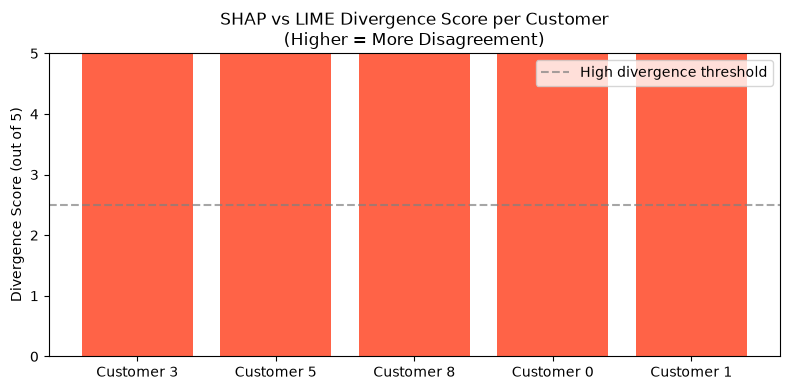


High divergence customers (score >= 3):
   customer_idx    actual  churn_prob  divergence_score
0             3     Churn       0.114                 5
1             5     Churn       0.525                 5
2             8     Churn       0.644                 5
3             0  No Churn       0.010                 5
4             1  No Churn       0.753                 5


In [7]:
fig, ax = plt.subplots(figsize=(8, 4))

colors = ['tomato' if s >= 3 else 'steelblue' for s in divergence_df['divergence_score']]

ax.bar(
    [f"Customer {i}" for i in divergence_df['customer_idx']],
    divergence_df['divergence_score'],
    color=colors
)
ax.axhline(y=2.5, color='gray', linestyle='--', alpha=0.7, label='High divergence threshold')
ax.set_title('SHAP vs LIME Divergence Score per Customer\n(Higher = More Disagreement)')
ax.set_ylabel('Divergence Score (out of 5)')
ax.set_ylim(0, 5)
ax.legend()

plt.tight_layout()
plt.savefig('../data/divergence_chart.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nHigh divergence customers (score >= 3):")
high_div = divergence_df[divergence_df['divergence_score'] >= 3]
print(high_div[['customer_idx', 'actual', 'churn_prob', 'divergence_score']])

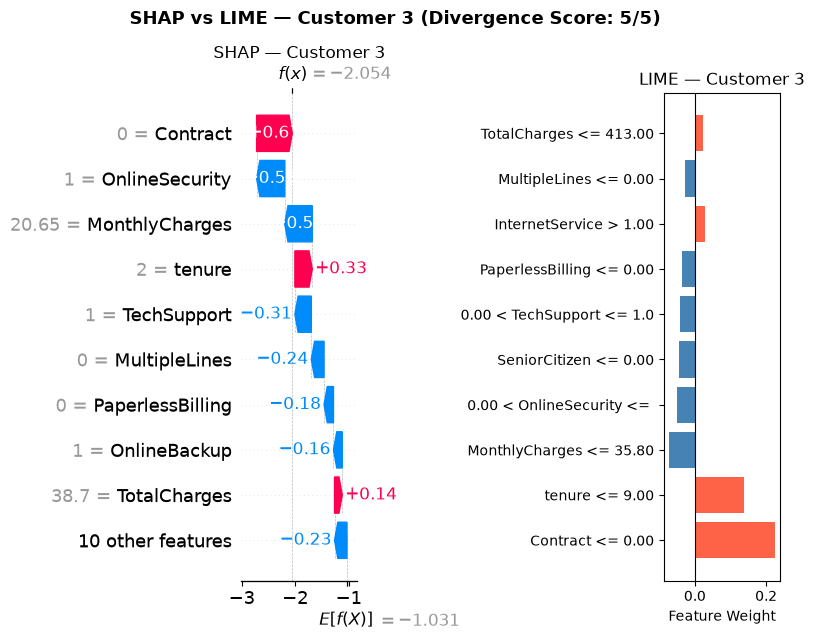

In [8]:
# Pick the most interesting customer — highest divergence
top_div_idx = divergence_df.loc[divergence_df['divergence_score'].idxmax(), 'customer_idx']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# SHAP waterfall
shap_exp = shap.Explanation(
    values        = shap_values_xgb[top_div_idx],
    base_values   = explainer_xgb.expected_value,
    data          = X_test.iloc[top_div_idx].values,
    feature_names = feature_names
)
plt.sca(axes[0])
shap.waterfall_plot(shap_exp, show=False)
axes[0].set_title(f'SHAP — Customer {top_div_idx}')

# LIME bar
lime_exp   = lime_explanations[top_div_idx]
lime_items = lime_exp.as_list()
lime_feats = [x[0][:25] for x in lime_items]  # truncate long names
lime_vals  = [x[1] for x in lime_items]
colors     = ['tomato' if v > 0 else 'steelblue' for v in lime_vals]

axes[1].barh(lime_feats, lime_vals, color=colors)
axes[1].set_title(f'LIME — Customer {top_div_idx}')
axes[1].set_xlabel('Feature Weight')
axes[1].axvline(x=0, color='black', linewidth=0.8)

plt.suptitle(f'SHAP vs LIME — Customer {top_div_idx} (Divergence Score: '
             f'{divergence_df[divergence_df["customer_idx"]==top_div_idx]["divergence_score"].values[0]}/5)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/shap_vs_lime_comparison.png', dpi=150, bbox_inches='tight')
plt.show()